# 贪心算法

## 题目目录

- [122-8 买卖股票的最佳时机 II](#lc-122)
- [188-9 买卖股票的最佳时机 IV](#lc-188)
- [309-10 买卖股票的最佳时机含冷冻期](#lc-309)
- [55-1 跳跃游戏](#lc-55)
- [45-11 跳跃游戏 II](#lc-45)


<a id="lc-122"></a>

## 122-8 买卖股票的最佳时机 II


### 买卖股票问题：（状态机DP）
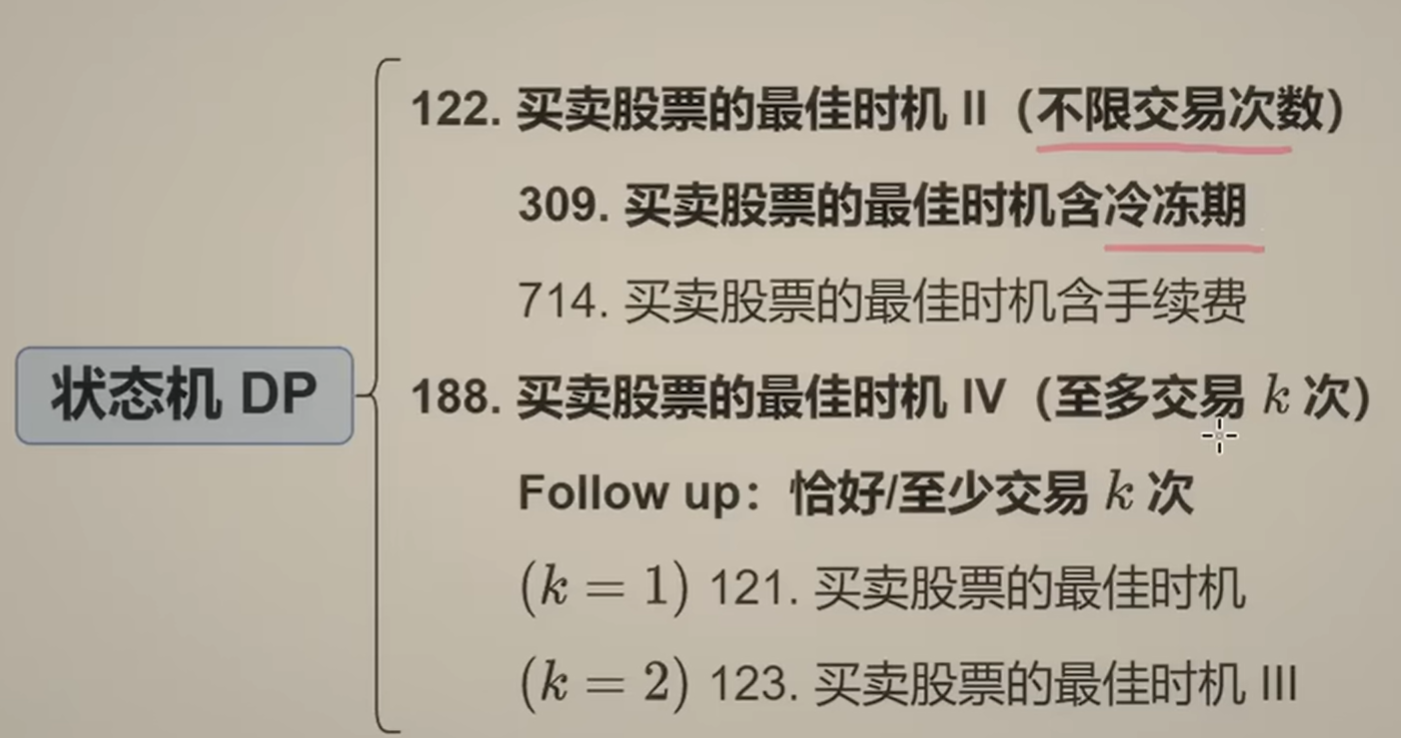
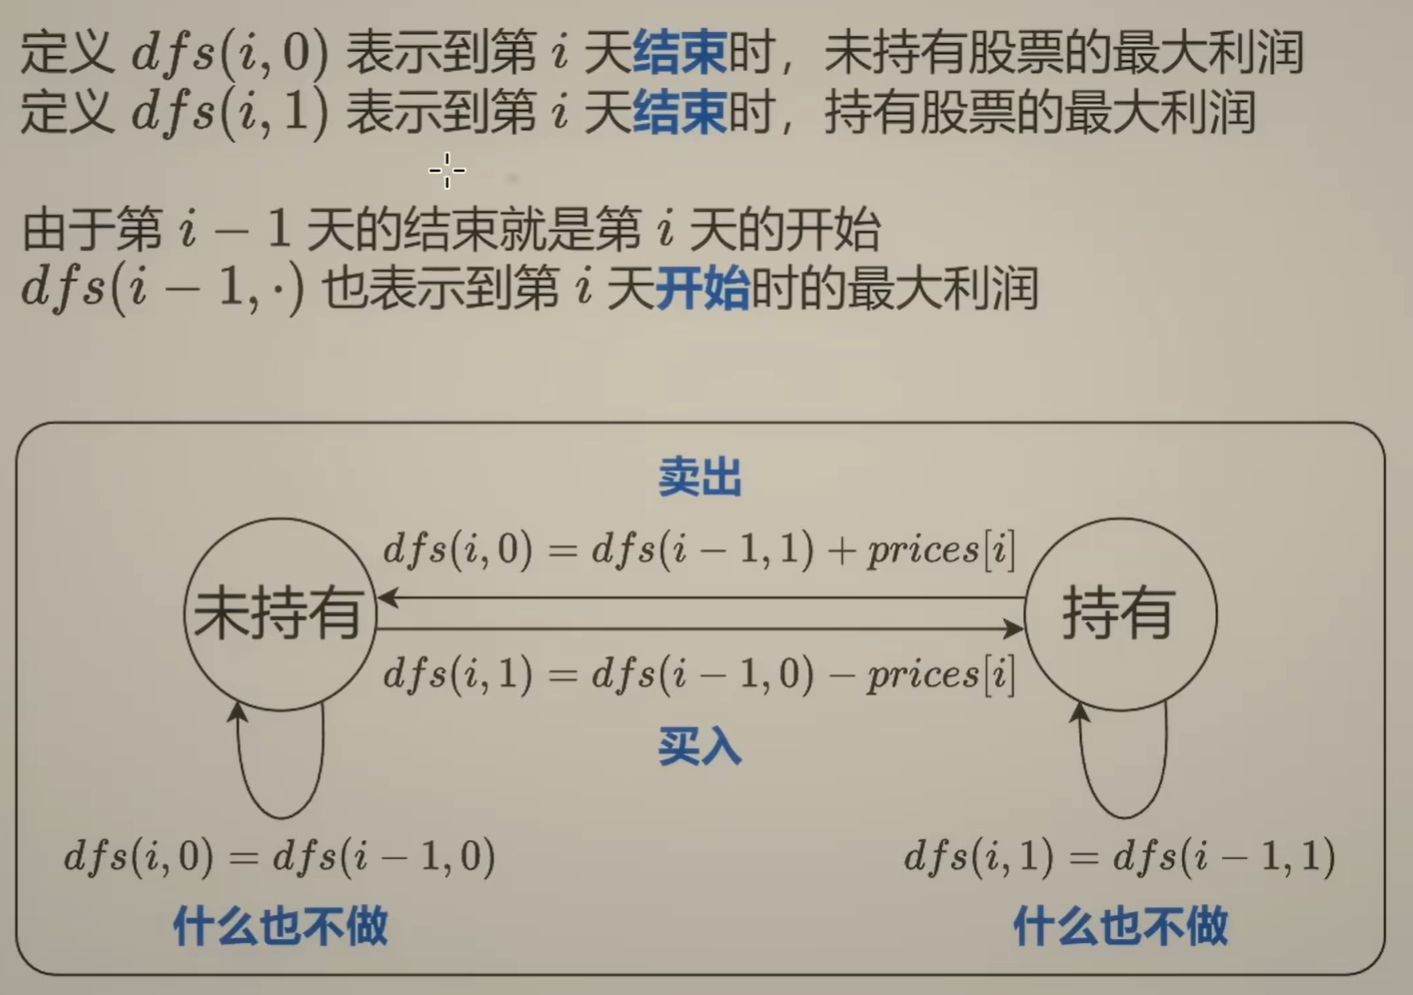


### 不限制交易次数：


    #没有冷冻期
    #1.递归写法：
    class Solution:
        def maxProfit(self, prices) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold):
                if i < 0:
                    return -inf if hold else 0#当第0天有股票不合法，第0天无股票返回0
                if hold:
                    return max(dfs(i-1,True),dfs(i-1,False)-prices[i])
                else:
                    return max(dfs(i-1,False),dfs(i-1,True)+prices[i])

        # return dfs(n-1,False)

    #2.动态规划写法：
        f0 = 0
        f1 = -inf

        for i,price in enumerate(prices):#天数与价值是一一对应的，因此不能使用两个循环
            new_f0 = max(f0,f1 + price)
            f1 = max(f1,f0 - price)
            f0 = new_f0

        return f0


<a id="lc-188"></a>

## 188-9 买卖股票的最佳时机 IV


### 限制交易次数：
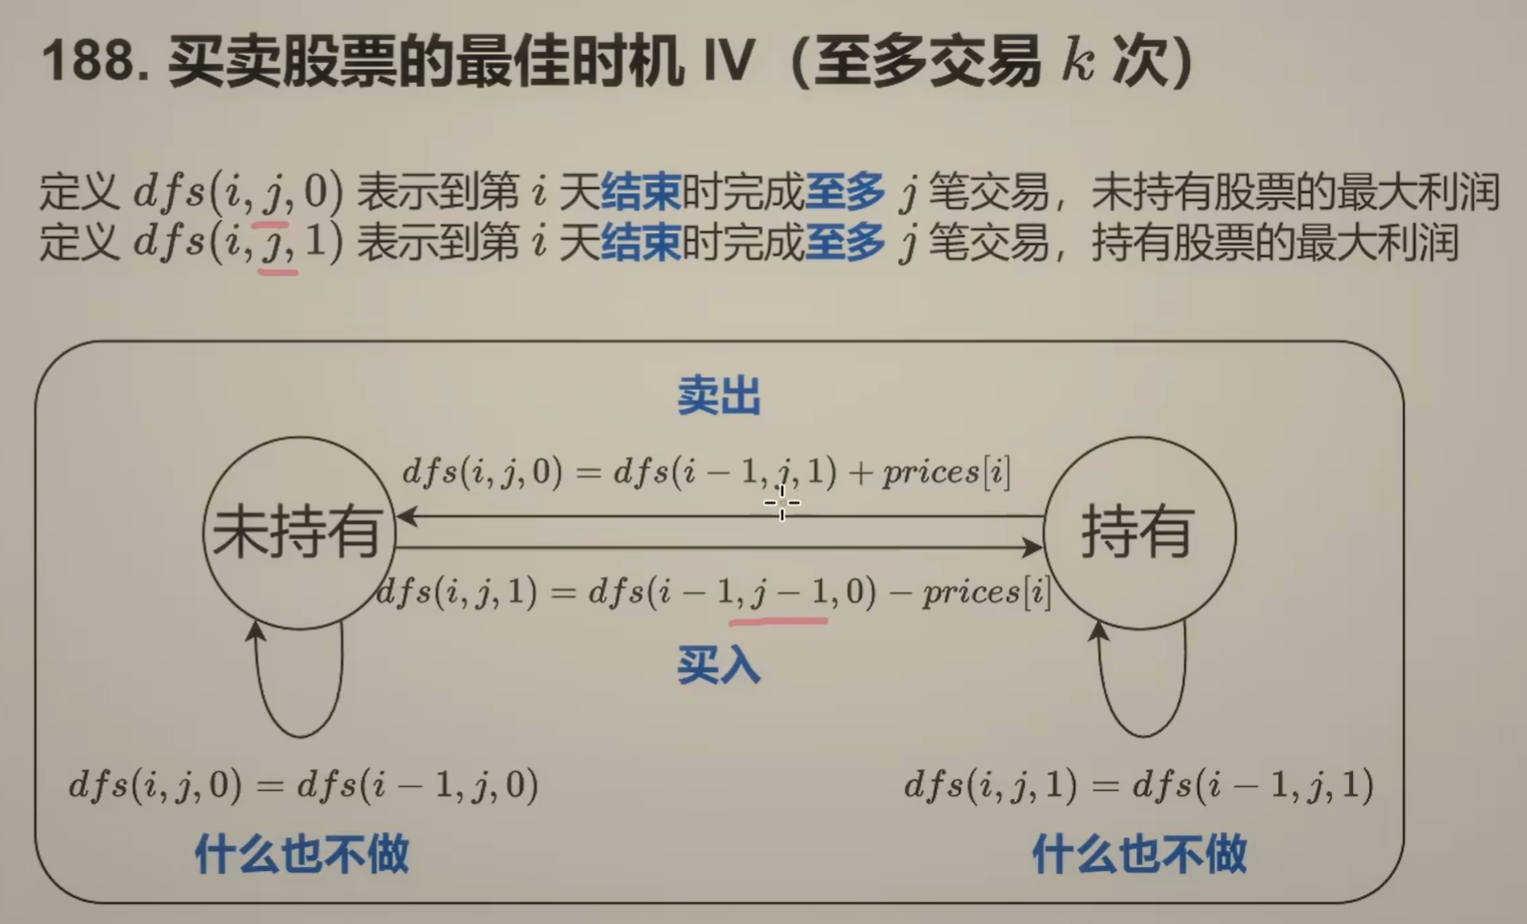


### 至多交易k次的问题：

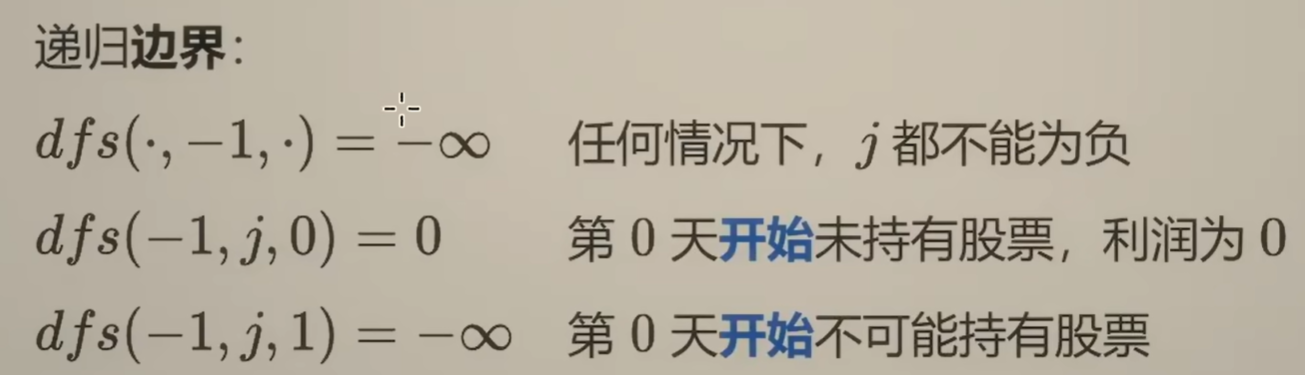
对于操作数而言，等于0意味着什么也没做，大于0代表着完成了k笔交易，只有当小于0的时候是不合法的，因此对于一个至多交易k次的问题，应该有k+2个空间来存储不同的情况



    #递归写法
    class Solution:
        def maxProfit(self, k: int, prices: List[int]) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold,j):
                if j < 0:#当操作数为0时意味着什么也不做，仍然是有意义的
                    return -inf
                if i < 0:
                    return -inf if hold else 0
                if hold:
                    return max(dfs(i-1,True,j),dfs(i-1,False,j)-prices[i])
                else:
                    return max(dfs(i-1,False,j),dfs(i-1,True,j-1)+prices[i])

        return dfs(n-1,False,k)

     #动态规划写法
        f = [[-inf]*2 for _ in range(k+2)]#存储的是在操作数为k的情况下昨天持有或未持有股票赚的钱数，更新后
                                          变成今天。
                                          #循环到第i天的时候第i-1天的状态
        for j in range(1,k+2):
            f[j][0] = 0
        for i,p in enumerate(prices):#这里写两重循环的原因在于存在交易数的限制，计算出当前这一天买入或者卖出
                                      股票时不同操作数能获取的最大价值
            for j in range(k+1,0,-1):#倒序更新保证了在计算f[j][0]时，f[j-1][1]是来自前一天的状态，而不是今天刚
            更新过的状态。这是典型的动态规划中避免状态被当前轮次污染的技术，类似于01背包问题中为了避免重复选取物品
            而采用倒序遍历容量。

                f[j][1] = max(f[j][1],f[j][0] - p)#先更新买入在更新卖出
                f[j][0] = max(f[j][0],f[j-1][1] + p)
        return f[k+1][0]


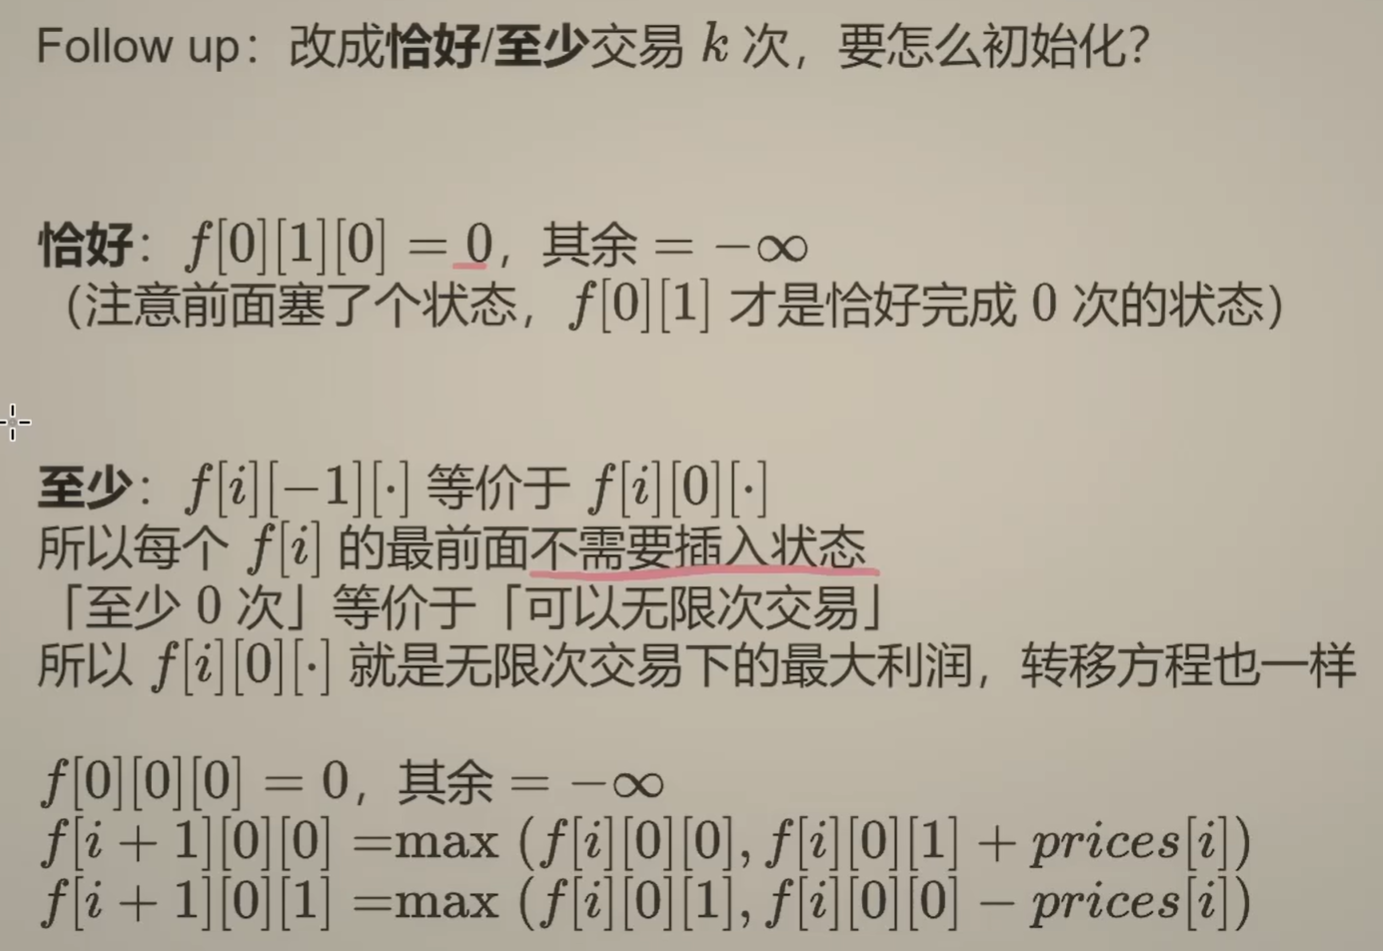


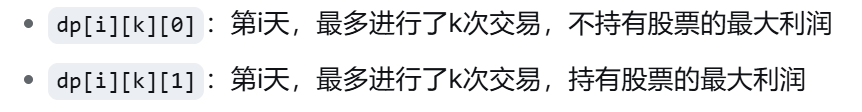

f[i+1][0][.]的含义是在第i+1天交易数至少为0的情况下持有股票与不持有股票所能获得最大利润，就是无限次交易下的最大利润

对于恰好完成k次的问题，若用一个二维数组进行初始化，那么f[1][0]就代表着第-1天操作数为0的情况下不持有股票的利润，此时为0是合理的，持有股票不合理，而对于操作数大于0的情况，因为这时候还没接触到股票，所以不可能有买与卖的操作，因此都是非法的，这一点与至多交易k次不同，对于第-1天没有接触到股票，至多交易k次的话在此时也只能交易0次，0次包含在k次内，有合法的结果，因此初始化为0.


In [ ]:
from cmath import inf

# 恰好
class Solution:
    def maxProfit(self, k: int, prices) -> int:
        # 递推
        n = len(prices)
        f = [[[-inf] * 2 for _ in range(k + 2)] for _ in range(n + 1)]
        f[0][1][0] = 0  # 只需改这里
        for i, p in enumerate(prices):
            for j in range(1, k + 2):
                f[i + 1][j][0] = max(f[i][j][0], f[i][j][1] + p)
                f[i + 1][j][1] = max(f[i][j][1], f[i][j - 1][0] - p)
        return f[-1][-1][0]

        # 记忆化搜索
        # @cache
        # def dfs(i: int, j: int, hold: bool) -> int:
        #     if j < 0:
        #         return -inf
        #     if i < 0:
        #         return -inf if hold or j > 0 else 0
        #     if hold:
        #         return max(dfs(i - 1, j, True), dfs(i - 1, j - 1, False) - prices[i])
        #     return max(dfs(i - 1, j, False), dfs(i - 1, j, True) + prices[i])
        # return dfs(n - 1, k, False)

In [ ]:
# 至少
class Solution:
    def maxProfit(self, k: int, prices) -> int:
        # 递推
        n = len(prices)
        f = [[[-inf] * 2 for _ in range(k + 1)] for _ in range(n + 1)]
        f[0][0][0] = 0#第一天，操作数至少为0，不持有股票的利润为0
        for i, p in enumerate(prices):
            f[i + 1][0][0] = max(f[i][0][0], f[i][0][1] + p)
            f[i + 1][0][1] = max(f[i][0][1], f[i][0][0] - p)  # 无限次
            for j in range(1, k + 1):
                f[i + 1][j][0] = max(f[i][j][0], f[i][j][1] + p)
                f[i + 1][j][1] = max(f[i][j][1], f[i][j - 1][0] - p)
        return f[-1][-1][0]

        # 记忆化搜索
        # @cache
        # def dfs(i: int, j: int, hold: bool) -> int:
        #     if i < 0:
        #         return -inf if hold or j > 0 else 0
        #     if hold:
        #         return max(dfs(i - 1, j, True), dfs(i - 1, j - 1, False) - prices[i])
        #     return max(dfs(i - 1, j, False), dfs(i - 1, j, True) + prices[i])
        # return dfs(n - 1, k, False)

<a id="lc-309"></a>

## 309-10 买卖股票的最佳时机含冷冻期


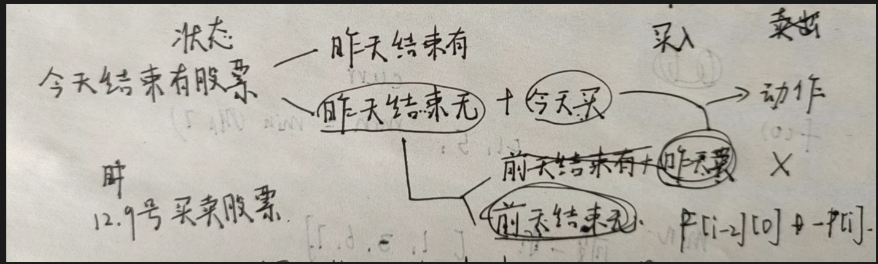

当你在昨天卖出股票后今天就不能买入股票了，因此在今天有股票的情况下，昨天无股票与前天无股票是等价的


    #存在冷冻期：
    #1.递归写法：
    class Solution:
        def maxProfit(self, prices: List[int]) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold):
                if i < 0:
                    return -inf if hold else 0
                if hold:
                    return max(dfs(i-1,True),dfs(i-2,False)-prices[i])
                else:
                    return max(dfs(i-1,False),dfs(i-1,True)+prices[i])

        return dfs(n-1,False)

    #2.动态规划写法
        f0 = 0 #昨天
        f1 = -inf #昨天
        f2 = 0 #前天

        for i,price in enumerate(prices):#天数与价值是一一对应的，因此不能使用两个循环
            new_f0 = max(f0,f1 + price)
            f1 = max(f1,f2 - price)
            f2 = f0
            f0 = new_f0

        return f0


<a id="lc-55"></a>

## 55-1 跳跃游戏


### 解题思路


### 贪心写法


In [ ]:
class Solution(object):
    def canJump(self, nums):
        """
        :type nums: List[int]
        :rtype: bool
        """
        t = len(nums) - 1

        for i in range(len(nums)-2,-1,-1):
            if i + nums[i] >= t:
                t = i#对于这一种写法而言，会不断的把希望到达的点前移，如果更前面的点连t这个比较前面的点都无法到达的话，那就更不用讨论能否到达后面的点了

        return t == 0

### 动态规划写法


In [ ]:
class Solution(object):
    def canJump(self, nums):
        """
        :type nums: List[int]
        :rtype: bool
        """
        n = len(nums)
        dp = [False] * n
        dp[0] = True

        for i in range(n-1):
            for j in range(1,nums[i]+1):
                if i + j < n and dp[i] == True:
                    dp[i+j] = True

        return dp[n-1]

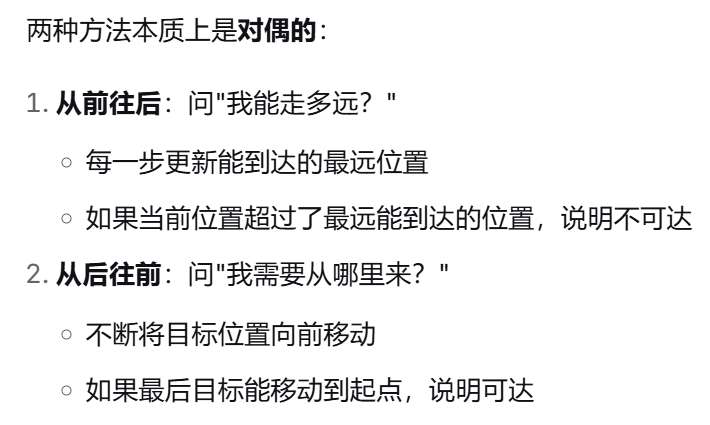


<a id="lc-45"></a>

## 45-11 跳跃游戏 II


跳跃游戏II

这个题的思路在于覆盖区间的确定，最开始时覆盖区间为0，因此肯定需要一次跳跃使其跳到下一个目前尚不知道的覆盖区域当中去，在遍历下一个覆盖区域的元素时（对于这个区域内的元素，只需走一次就能走到）记录目前能走到的最远索引值是多少，当走到这个区域的最后一个值的时候，就需要扩大覆盖区域的大小，又因为后面的元素走一步肯定是走不到的，所以步数需要加一

**_"在每一跳的范围内，找到下一跳能跳得最远的点作为落脚点"_**

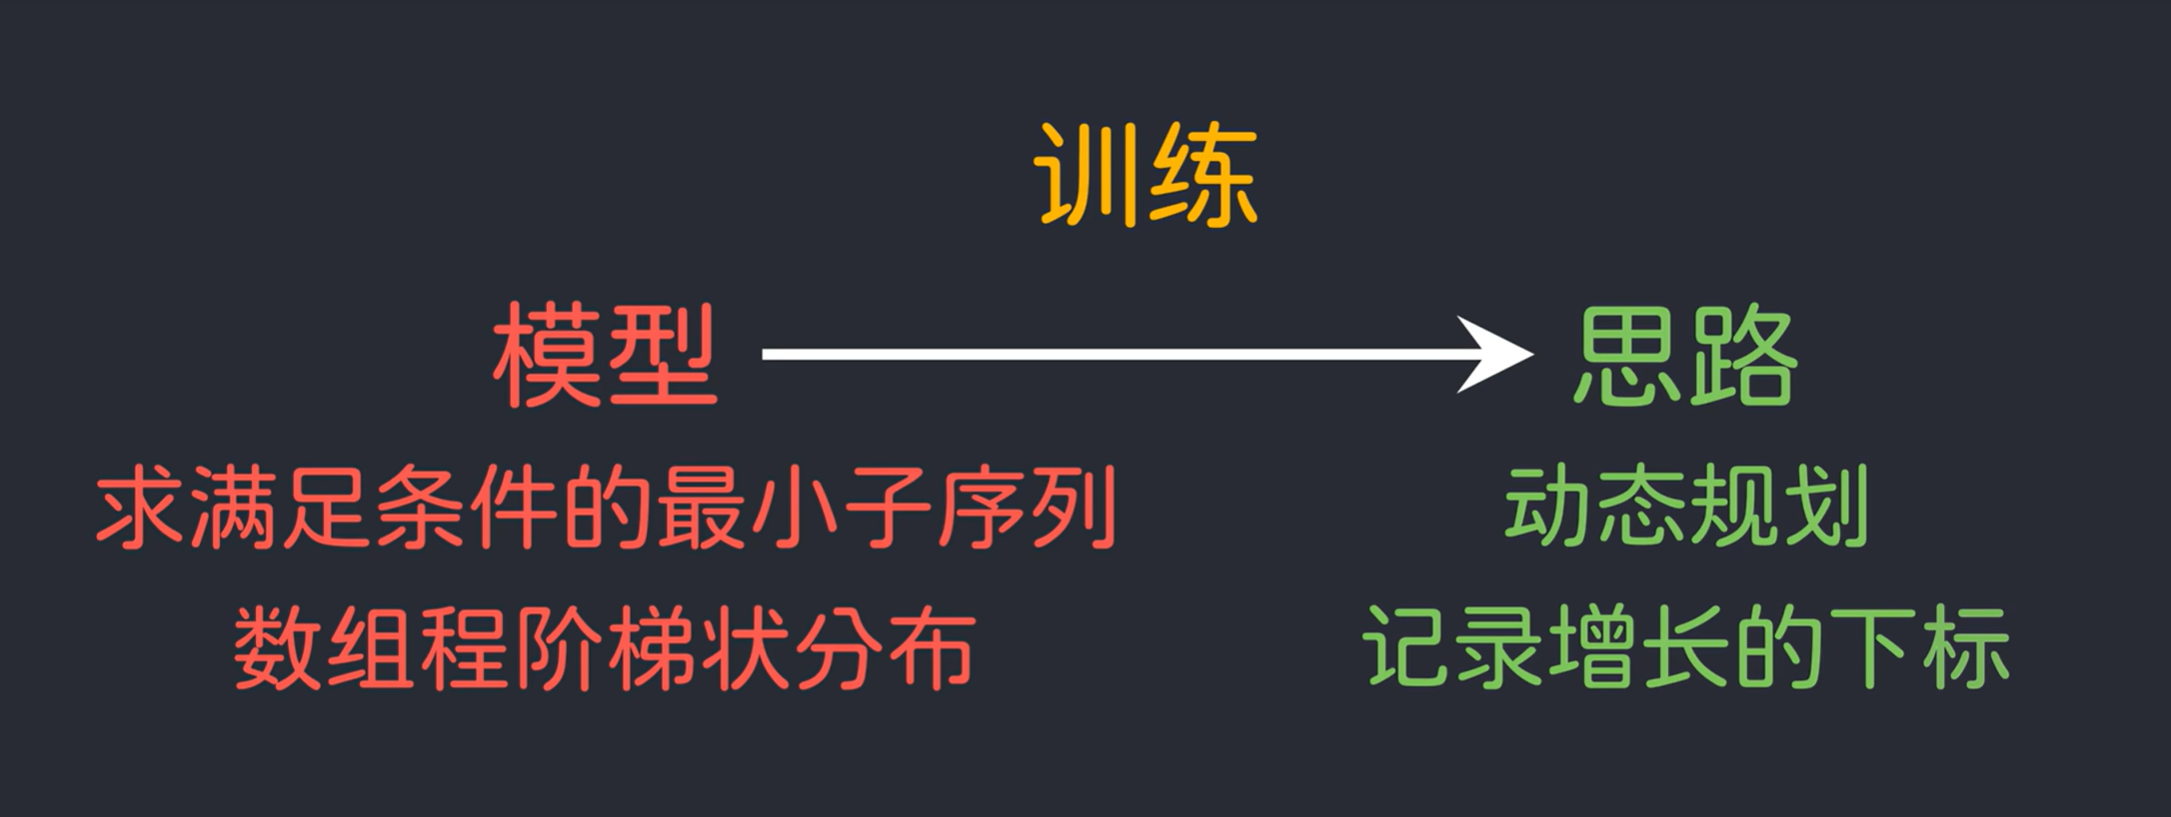


条件:从头走到尾

最小子序列:走过的步数最少，涉及到的元素的个数最少，也即最小子序列


In [ ]:
class Solution(object):#只能记录从起点到终点的最少步数，中间的无法记录
    def jump(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        step = curr_end = farset_end = 0

        for i in range(len(nums) - 1):#不会遍历到最后一个元素，从而避免了一次i == farest_end的判断
            curr_end = max(curr_end,i + nums[i])#更新下一步跳跃后能够到达的最远位置

            if i == farset_end:
                step += 1
                farset_end = curr_end #在进行这一步操作的时候，其实就是确定了应该以当前覆盖区域的哪一个元素为新的起点

        return step

In [1]:
class Solution(object):
    def jump(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        #dp写法
        n = len(nums)
        dp = [float('inf')] * n #不用设置判断节点是否可达的列表，因为距离列表的值初始化为无穷大，如果当前节点无法到达的话，那么dp[i+j],dp[i]+1的最小值还是无穷大，索引上的值为无穷大就意味着这个点不可达
        dp[0] = 0

        for i in range(n-1):
            for j in range(1,nums[i]+1):
                if i + j < n:
                    dp[i+j] = min(dp[i+j],dp[i]+1)#这个问题也可以看成一个爬台阶问题，最开始时我们位于台阶0，需要跳一步走到台阶1，而当我们遇到台阶一的最后一个值的时候，我们又需要再跳一步爬到台阶2，因此我们只需要记录每个台阶的最后一个数的索引即可，当遍历到这索引的时候就必须跳一步以到达后面的位置

                    #对于同一个元素，先被遍历到的步数一定比后被遍历到的步数少，简单来说就是一步就能做到的事情就不要两步
        return dp[n-1]